# Recreate the GAAE/GELSTM leakage bug: before vs after

Replay-only reproduction — no retraining. Every artifact plotted here already exists on
disk (the historical "before"/"after" `run_summary.json` files and the historical leaky
split JSONs); this notebook just reloads and replots them with the same style as the two
source notebooks. See `../gaae-downstream-leakage-investigation.md` for the full writeup
this reproduces, and `old_gelstm/README.md` for provenance of the frozen legacy code
sitting alongside this notebook.

**What this shows:** the *mechanism* of the leak (split-overlap panel), and the *bundled*
historical AUC comparison as the supervisor originally saw it (leaderboard + ROC panels).
**What this does not show:** the leak's isolated contribution — the 0.967→0.807 drop
also bundles an encoder swap and a downstream hyperparameter shrink (see Attribution
section of the linked doc). That would require actually retraining, out of scope here.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.special import ndtri, ndtr
from sklearn.metrics import roc_auc_score, roc_curve

HERE = Path.cwd()
REPO_ROOT = HERE.parents[2] if (HERE / "run_summaries").exists() else HERE
SRC = REPO_ROOT / "DOCS" / "seventh-meeting-tasks" / "src" if not (HERE / "run_summaries").exists() else HERE
print("Reading artifacts from:", SRC)


Reading artifacts from: /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src


## 1. Split-leak evidence panel

Leaky (legacy) split vs the current, fixed split — same overlap check `verify_legacy_split_overlap.py` already runs, plus the live current-split equivalent.

In [2]:
LEGACY_SPLITS = SRC / "splits" / "legacy"
gaae_legacy = json.load(open(LEGACY_SPLITS / "gaae_data_splits.json"))
gec_legacy = json.load(open(LEGACY_SPLITS / "gec_data_splits.json"))

gaae_train_legacy = set(gaae_legacy["train"].keys())
gec_test_legacy = set(gec_legacy["test"].keys())
gec_val_legacy = set(gec_legacy["validation"].keys())

legacy_train_test_overlap = len(gaae_train_legacy & gec_test_legacy)
legacy_train_val_overlap = len(gaae_train_legacy & gec_val_legacy)

print(f"[legacy]  GAAE train ∩ GEC test = {legacy_train_test_overlap}  (protected)")
print(f"[legacy]  GAAE train ∩ GEC val  = {legacy_train_val_overlap} / {len(gec_val_legacy)}  (the leak)")


[legacy]  GAAE train ∩ GEC test = 0  (protected)
[legacy]  GAAE train ∩ GEC val  = 69 / 106  (the leak)


In [3]:
CURRENT_SPLITS = REPO_ROOT / "DATA" / "DELCODE" / "__metadata__" / "SPLITS"

pretrain_train_current = set(pd.read_csv(CURRENT_SPLITS / "pretrain" / "train.csv")["Pseudonym"])
downstream_test_current = set(pd.read_csv(CURRENT_SPLITS / "downstream" / "test.csv")["Pseudonym"])
downstream_val_current = set(pd.read_csv(CURRENT_SPLITS / "downstream" / "val.csv")["Pseudonym"])

current_train_test_overlap = len(pretrain_train_current & downstream_test_current)
current_train_val_overlap = len(pretrain_train_current & downstream_val_current)

print(f"[current] pretrain train ∩ downstream test = {current_train_test_overlap}  (protected)")
print(f"[current] pretrain train ∩ downstream val  = {current_train_val_overlap} / {len(downstream_val_current)}  (fixed)")


[current] pretrain train ∩ downstream test = 0  (protected)
[current] pretrain train ∩ downstream val  = 0 / 34  (fixed)


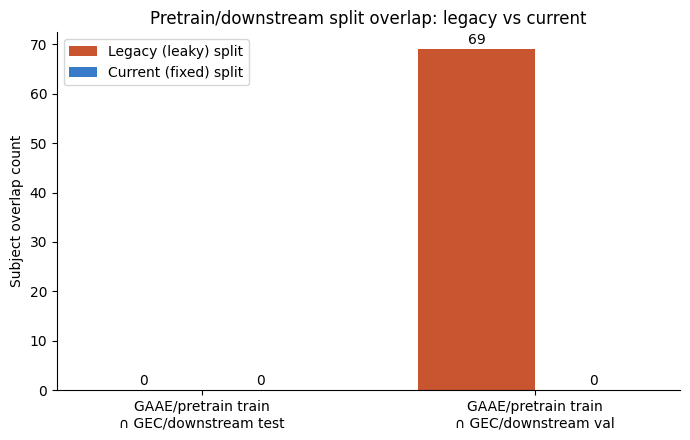

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["GAAE/pretrain train\n∩ GEC/downstream test", "GAAE/pretrain train\n∩ GEC/downstream val"]
legacy_vals = [legacy_train_test_overlap, legacy_train_val_overlap]
current_vals = [current_train_test_overlap, current_train_val_overlap]

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, legacy_vals, width, label="Legacy (leaky) split", color="#BF360C", alpha=0.85)
ax.bar(x + width/2, current_vals, width, label="Current (fixed) split", color="#1565C0", alpha=0.85)

for i, v in enumerate(legacy_vals):
    ax.text(i - width/2, v + 1, str(v), ha="center", fontsize=10)
for i, v in enumerate(current_vals):
    ax.text(i + width/2, v + 1, str(v), ha="center", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Subject overlap count")
ax.set_title("Pretrain/downstream split overlap: legacy vs current")
ax.legend()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()


## 2. Leaderboard replay (5-fold CV AUROC)

Same `barh` + error-bar + fold-dot pattern as
`BASELINE_MODEL_COMPARISON_DELCODE_WHOLE_BRAIN.ipynb`'s leaderboard cell — reads
straight from the two saved `run_summary.json` dicts, no live model needed.

In [5]:
before = json.load(open(SRC / "run_summaries" / "before.json"))
after = json.load(open(SRC / "run_summaries" / "after.json"))

summaries = {"GELSTM — before (bright-disco-4, leaky split)": before,
             "GELSTM — after (ethereal-planet-16, fixed split)": after}
colors = {"GELSTM — before (bright-disco-4, leaky split)": "#BF360C",
          "GELSTM — after (ethereal-planet-16, fixed split)": "#1565C0"}

for name, s in summaries.items():
    cv = np.array(s["cv_results"]["val_auc"])
    print(f"{name}: CV={cv.mean():.3f}±{cv.std():.3f}  test_auc={s.get('test_auc')}")


GELSTM — before (bright-disco-4, leaky split): CV=0.944±0.058  test_auc=0.9666666666666668
GELSTM — after (ethereal-planet-16, fixed split): CV=0.944±0.023  test_auc=0.8071428571428572


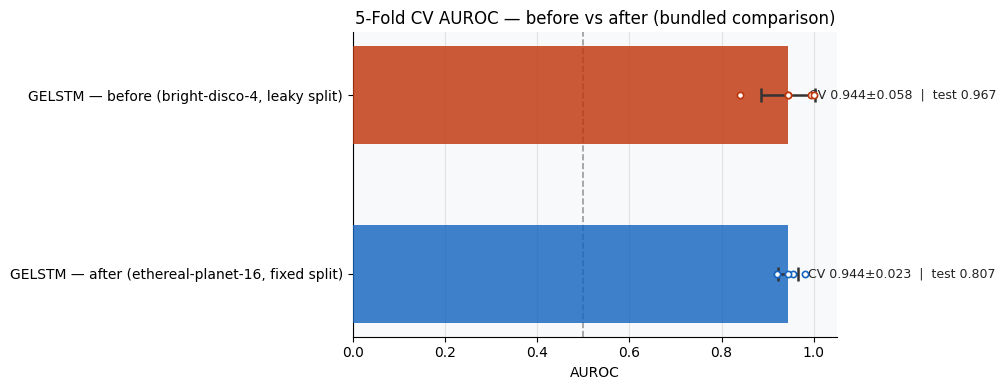

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("white")

names = list(summaries.keys())
n = len(names)
for i, name in enumerate(reversed(names)):
    s = summaries[name]
    aucs = np.array(s["cv_results"]["val_auc"])
    mu, sigma = aucs.mean(), aucs.std()
    color = colors[name]
    ax.barh(i, mu, color=color, alpha=0.82, height=0.55, linewidth=0, zorder=3)
    ax.errorbar(mu, i, xerr=sigma, fmt="none", ecolor="#333", elinewidth=1.8, capsize=5, capthick=1.8, zorder=4)
    ax.scatter(aucs, [i] * len(aucs), color="white", s=20, edgecolors=color, linewidths=1.2, zorder=5)
    test_auc = s.get("test_auc")
    label = f"CV {mu:.3f}±{sigma:.3f}" + (f"  |  test {test_auc:.3f}" if test_auc is not None else "")
    ax.text(min(mu + sigma + 0.02, 0.99), i, label, va="center", ha="left", fontsize=9, color="#222")

ax.set_yticks(range(n))
ax.set_yticklabels(list(reversed(names)), fontsize=10)
ax.set_xlim(0, 1.05)
ax.axvline(0.5, color="#999", linestyle="--", lw=1.2)
ax.set_xlabel("AUROC")
ax.set_title("5-Fold CV AUROC — before vs after (bundled comparison)")
ax.grid(axis="x", alpha=0.3, zorder=0)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()


## 3. Test-set ROC replay

Reuses `CLASSIFIER/common/plots.py::plot_oof_test_roc`'s test-set panel logic
(`roc_curve`/`roc_auc_score`). `after.json` stores raw `test_probabilities`/
`test_labels`, so its curve is exact. `before.json` predates that schema — no raw test
predictions were saved — so its curve falls back to the same binormal approximation
(`approx_roc_from_auc`) the BASELINE notebook uses, and is drawn dashed and labelled
"approx" so it can't be mistaken for an exact curve.

The pooled **out-of-fold** ROC panel (the left half of `plot_oof_test_roc`) is **not**
reproduced here — per-subject OOF predictions aren't persisted in either
`run_summary.json`, and regenerating them would require rerunning cross-validation,
which is out of scope for this replay-only notebook.

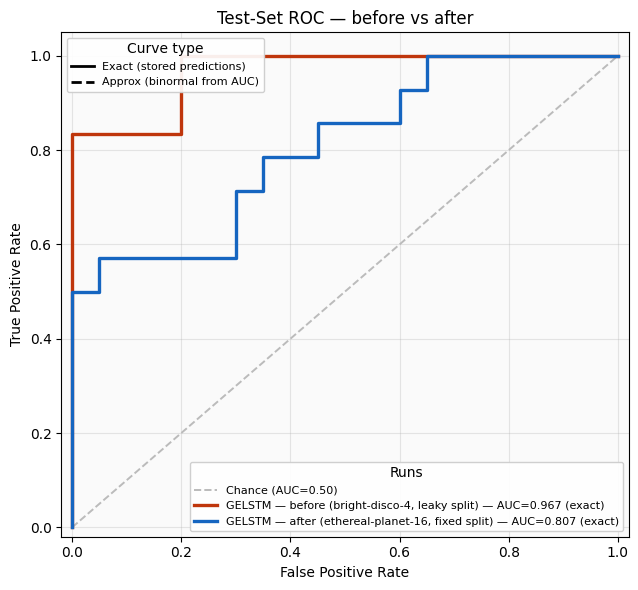

In [7]:
def approx_roc_from_auc(auc, n_pts=300):
    """Binormal-model ROC approximation from a scalar AUC value."""
    auc = float(np.clip(auc, 0.501, 0.999))
    a = ndtri(auc) * (2 ** 0.5)
    fpr = np.linspace(1e-4, 1 - 1e-4, n_pts)
    tpr = ndtr(a + ndtri(fpr))
    return np.r_[0, fpr, 1], np.r_[0, tpr, 1]


fig, ax = plt.subplots(figsize=(6.5, 6))
ax.set_facecolor("#FAFAFA")
ax.plot([0, 1], [0, 1], "--", color="#BBB", lw=1.4, label="Chance (AUC=0.50)")

for name, s in summaries.items():
    color = colors[name]
    probs = s.get("test_probabilities")
    labs = s.get("test_labels")
    test_auc = s.get("test_auc")
    cv_mu = float(np.mean(s["cv_results"]["val_auc"]))

    if probs is not None and labs is not None and len(np.unique(labs)) > 1:
        fpr, tpr, _ = roc_curve(labs, probs)
        auc_val = roc_auc_score(labs, probs)
        ax.plot(fpr, tpr, lw=2.4, color=color, label=f"{name} — AUC={auc_val:.3f} (exact)")
    else:
        auc_for_approx = test_auc if test_auc is not None else cv_mu
        fpr_a, tpr_a = approx_roc_from_auc(auc_for_approx)
        ax.plot(fpr_a, tpr_a, lw=2.0, color=color, ls="--", alpha=0.8,
                label=f"{name} — AUC={auc_for_approx:.3f} (approx, no raw predictions saved)")

style_legend = [
    Line2D([0], [0], color="k", lw=2, ls="-", label="Exact (stored predictions)"),
    Line2D([0], [0], color="k", lw=2, ls="--", label="Approx (binormal from AUC)"),
]
l1 = ax.legend(loc="lower right", fontsize=8, framealpha=0.92, title="Runs")
ax.add_artist(l1)
ax.legend(handles=style_legend, loc="upper left", fontsize=8, framealpha=0.92, title="Curve type")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Test-Set ROC — before vs after")
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()


## Takeaway

This replay reproduces the historical comparison exactly as originally seen — leaky
split (69/106 val overlap) → `bright-disco-4` encoder → old hardcoded GELSTM script
(0.967 test AUC) versus fixed split (0 overlap) → `ethereal-planet-16` encoder → adapter
framework (0.807 test AUC). **It is not evidence that the leak alone caused the drop**:
the encoder and downstream hyperparameters (LSTM hidden size, feature standardization,
weight decay) changed in the same window. See the Attribution section of
`../gaae-downstream-leakage-investigation.md` for the full breakdown, and its Hardening
recommendations for what would make this kind of question answerable without archaeology
next time (e.g. recording a split-file hash per run).